# Analisis de visitas a Showz desde enero de 2017 hasta diciembre de 2018

### Importamos librerias a utilizar

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

### Importamos los archivos de los Datasets

In [2]:
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

### Estudiamos los datos que contienen los Datasets

In [3]:
visits.info()
print()
visits.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB



,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [4]:
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [5]:
orders.info()
print()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB



,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [6]:
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [7]:
costs.info()
print()
costs.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB



,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [8]:
costs['dt'] = pd.to_datetime(costs['dt'])
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


## 1. Visitas:

* ¿Cuántas personas lo usan cada día, semana y mes?
* ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).
* ¿Cuál es la duración de cada sesión?
* ¿Con qué frecuencia los usuarios regresan?

In [9]:
visits.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


* Uid: identificador único del usuario.
* Device: dispositivo del usuario.
* Start Ts: fecha y hora de inicio de la sesión.
* End Ts: fecha y hora de término de la sesión.
* Source Id: identificador de la fuente de anuncios de la que proviene el usuario.

In [10]:
visits['session_year'] = visits['Start Ts'].dt.isocalendar().year
visits['session_month'] = visits['Start Ts'].dt.month
visits['session_week'] = visits['Start Ts'].dt.isocalendar().week
visits['session_date'] = visits['Start Ts'].dt.date
visits.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_year,session_month,session_week,session_date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017,12,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018,2,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017,7,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018,5,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017,12,52,2017-12-27


In [11]:
sessions_per_user = visits.groupby(['session_month', 'session_week', 'session_date']).agg(
    {'Uid': ['count', 'nunique']}
)
sessions_per_user.columns = ['n_sessions', 'n_users']
sessions_per_user['sessions_per_user'] = (
    sessions_per_user['n_sessions'] / sessions_per_user['n_users']
)
sessions_per_user

n_sessions  n_users  \
session_month session_week session_date                        
1             1            2018-01-01          1065      992   
                           2018-01-02          1355     1265   
                           2018-01-03          1317     1219   
                           2018-01-04          1370     1260   
                           2018-01-05          1092     1006   
...                                             ...      ...   
12            52           2017-12-27          1444     1334   
                           2017-12-28          1496     1377   
                           2017-12-29          1315     1192   
                           2017-12-30          1192     1106   
                           2017-12-31           784      732   

                                         sessions_per_user  
session_month session_week session_date                     
1             1            2018-01-01             1.073589  
                           2018-01-02             1.071146  
                           2018-01-03             1.080394  
                           2018-01-04             1.087302  
                           2018-01-05             1.085487  
...                                                    ...  
12            52           2017-12-27             1.082459  
                           2017-12-28             1.086420  
                           2017-12-29             1.103188  
                           2017-12-30             1.077758  
                           2017-12-31             1.071038  

[364 rows x 3 columns]

* ¿Cuántas personas lo usan cada día, semana y mes?

In [12]:
session_week = visits.groupby(['session_week']).agg(
    {'Uid': ['count']}
)
session_week.columns = ['n_sessions']

session_week

,n_sessions
session_week,
1,8057
2,7871
3,8317
4,8488
5,9796
6,9407
7,9272
8,8930
9,8771


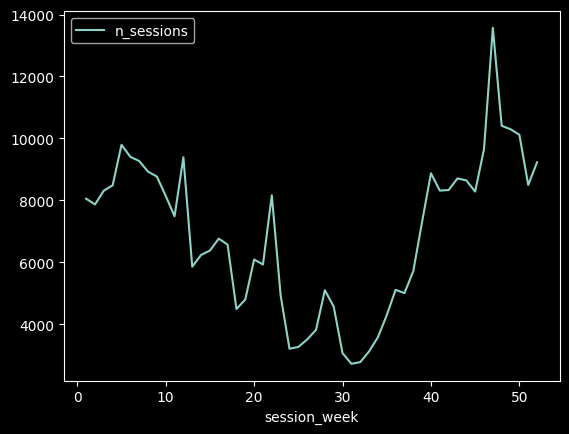

In [13]:
plt.style.use("dark_background")
session_week.plot()
plt.show()

In [14]:
session_month = visits.groupby(['session_month']).agg(
    {'Uid': ['count']}
)
session_month.columns = ['n_sessions']

session_month

,n_sessions
session_month,
1,36939
2,37182
3,35679
4,26515
5,26635
6,16505
7,17828
8,14355
9,23907


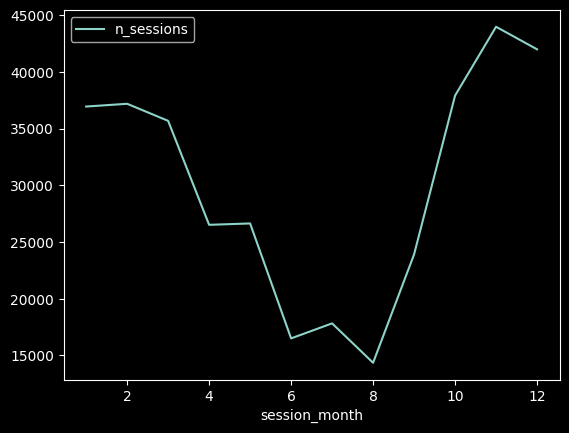

In [15]:
session_month.plot()
plt.show()

* ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

In [16]:
sessions_per_day = visits.groupby(['session_date']).agg(
    {'Uid': ['count']}
)
sessions_per_day.columns = ['n_sessions']

sessions_per_day

,n_sessions
session_date,
2017-06-01,664
2017-06-02,658
2017-06-03,477
2017-06-04,510
2017-06-05,893
...,...
2018-05-27,672
2018-05-28,1156
2018-05-29,1035


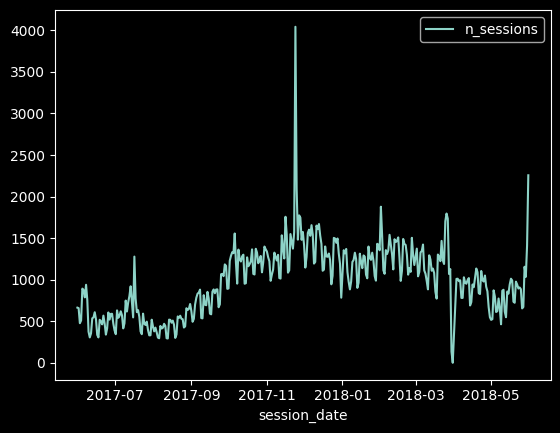

In [17]:
sessions_per_day.plot()
plt.show()

* ¿Cuál es la duración de cada sesión?

In [18]:
visits['session_duration_sec'] = (
    visits['End Ts'] - visits['Start Ts']).dt.seconds
visits['session_duration_sec']

0         1080
1         1680
2            0
3         1440
4            0
          ... 
359395      19
359396      19
359397      19
359398      19
359399      19
Name: session_duration_sec, Length: 359400, dtype: int64

<AxesSubplot:xlabel='session_duration_sec', ylabel='Count'>

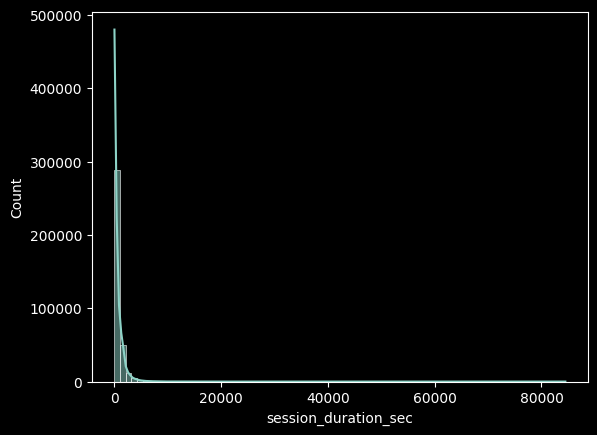

In [19]:
sns.histplot(visits['session_duration_sec'], bins=80, kde=True)

* ¿Con qué frecuencia los usuarios regresan?

In [20]:
dau_total = visits.groupby('session_date').agg(
    {'Uid': 'nunique'}).mean().item()
wau_total = (  # número de usuarios activos semanales
    visits.groupby(['session_year', 'session_week'])
    .agg({'Uid': 'nunique'})
    .mean()
    .item()
)
mau_total = (  # número de usuarios activos mensuales
    visits.groupby(['session_year', 'session_month'])
    .agg({'Uid': 'nunique'})
    .mean()
    .item()
)
sticky_wau = dau_total / wau_total * 100  # factor de adherencia semanal
print(f'Week {sticky_wau} %')
sticky_mau = dau_total / mau_total * 100  # factor de adherencia mensual
print(f'Month {sticky_mau} %')

Week 15.88440861589881 %
Month 3.908969652437603 %


## 2. Ventas:
* ¿Cuándo empieza la gente a comprar? 
* ¿Cuántos pedidos hacen durante un período de tiempo dado?
* ¿Cuál es el tamaño promedio de compra?
* ¿Cuánto dinero traen? (LTV)

In [21]:
orders.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


* Buy Ts: fecha y hora del pedido.
* Revenue: el ingreso de Showz por el pedido.
* Uid: identificador único del usuario que realiza un pedido.

<AxesSubplot:xlabel='Buy Ts', ylabel='Count'>

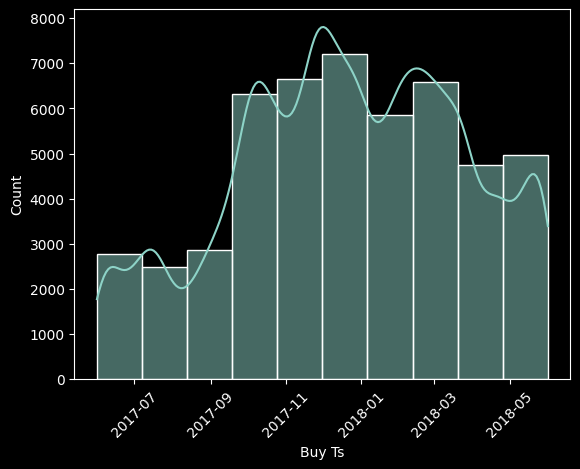

In [22]:
plt.xticks(rotation=45)  # gira las etiquetas en el eje X
sns.histplot(orders['Buy Ts'], bins=10, kde=True)

In [23]:
# agregamos la columna del mes para poder hacer cohortes mensuales
orders['order_month'] = orders['Buy Ts'].astype('datetime64[M]')
# recuperamos el mes de la primera compra de cada cliente
first_orders = orders.groupby('Uid').agg({'order_month': 'min'}).reset_index()
first_orders.columns = ['Uid', 'first_order_month']
first_orders.head()

,Uid,first_order_month
0,313578113262317,2018-01-01
1,1575281904278712,2017-06-01
2,2429014661409475,2017-10-01
3,2464366381792757,2018-01-01
4,2551852515556206,2017-11-01


In [24]:
cohort_sizes = first_orders.groupby('first_order_month').agg(
    {'Uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']
cohort_sizes

,first_order_month,n_buyers
0,2017-06-01,2023
1,2017-07-01,1923
2,2017-08-01,1370
3,2017-09-01,2581
4,2017-10-01,4340
5,2017-11-01,4081
6,2017-12-01,4383
7,2018-01-01,3373
8,2018-02-01,3651
9,2018-03-01,3533


In [25]:
orders_ = pd.merge(orders, first_orders, on='Uid')
orders_.head()

,Buy Ts,Revenue,Uid,order_month,first_order_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06-01


In [26]:
cohorts = orders_.groupby(['first_order_month', 'order_month']).agg(
    {'Revenue': 'sum'}).reset_index()
cohorts.head()

,first_order_month,order_month,Revenue
0,2017-06-01,2017-06-01,9557.49
1,2017-06-01,2017-07-01,981.82
2,2017-06-01,2017-08-01,885.34
3,2017-06-01,2017-09-01,1931.30
4,2017-06-01,2017-10-01,2068.58


In [27]:
report = pd.merge(cohort_sizes, cohorts, on='first_order_month')
report

,first_order_month,n_buyers,order_month,Revenue
0,2017-06-01,2023,2017-06-01,9557.49
1,2017-06-01,2023,2017-07-01,981.82
2,2017-06-01,2023,2017-08-01,885.34
3,2017-06-01,2023,2017-09-01,1931.30
4,2017-06-01,2023,2017-10-01,2068.58
...,...,...,...,...
74,2018-03-01,3533,2018-05-01,1114.87
75,2018-04-01,2276,2018-04-01,10600.69
76,2018-04-01,2276,2018-05-01,1209.92
77,2018-05-01,2988,2018-05-01,13925.76


In [28]:
report['age'] = (
    report['order_month'] - report['first_order_month']
) / np.timedelta64(1, 'M')
report['age'] = report['age'].round().astype('int')

report

,first_order_month,n_buyers,order_month,Revenue,age
0,2017-06-01,2023,2017-06-01,9557.49,0
1,2017-06-01,2023,2017-07-01,981.82,1
2,2017-06-01,2023,2017-08-01,885.34,2
3,2017-06-01,2023,2017-09-01,1931.30,3
4,2017-06-01,2023,2017-10-01,2068.58,4
...,...,...,...,...,...
74,2018-03-01,3533,2018-05-01,1114.87,2
75,2018-04-01,2276,2018-04-01,10600.69,0
76,2018-04-01,2276,2018-05-01,1209.92,1
77,2018-05-01,2988,2018-05-01,13925.76,0


In [29]:
margin_rate = 1

report['gp'] = report['Revenue'] * margin_rate
report['ltv'] = report['gp'] / report['n_buyers']

output = report.pivot_table(
    index='first_order_month',
    columns='age',
    values='ltv',
    aggfunc='mean').round()

output.fillna('')

age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,5.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2017-07-01,6.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
2017-08-01,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,
2017-09-01,6.0,1.0,1.0,4.0,0.0,1.0,1.0,0.0,0.0,,,
2017-10-01,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,,,,
2017-11-01,5.0,0.0,0.0,0.0,0.0,0.0,0.0,,,,,
2017-12-01,5.0,0.0,1.0,1.0,0.0,0.0,,,,,,
2018-01-01,4.0,0.0,0.0,0.0,0.0,,,,,,,
2018-02-01,4.0,0.0,0.0,0.0,,,,,,,,


In [30]:
ltv_201801 = output.loc['2018-01-01'].sum()
ltv_201801

4.0

## 3. Marketing:
* ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 
* ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
* ¿Cuán rentables eran las inversiones? (ROMI)

In [39]:
costs

,source_id,dt,costs,month
0,1,2017-06-01,75.20,2017-06-01
1,1,2017-06-02,62.25,2017-06-01
2,1,2017-06-03,36.53,2017-06-01
3,1,2017-06-04,55.00,2017-06-01
4,1,2017-06-05,57.08,2017-06-01
...,...,...,...,...
2537,10,2018-05-27,9.92,2018-05-01
2538,10,2018-05-28,21.26,2018-05-01
2539,10,2018-05-29,11.32,2018-05-01
2540,10,2018-05-30,33.15,2018-05-01


* source_id: identificador de la fuente de anuncios.
* dt: fecha.
* costs: gastos en esta fuente de anuncios en este día.

<AxesSubplot:xlabel='dt', ylabel='Count'>

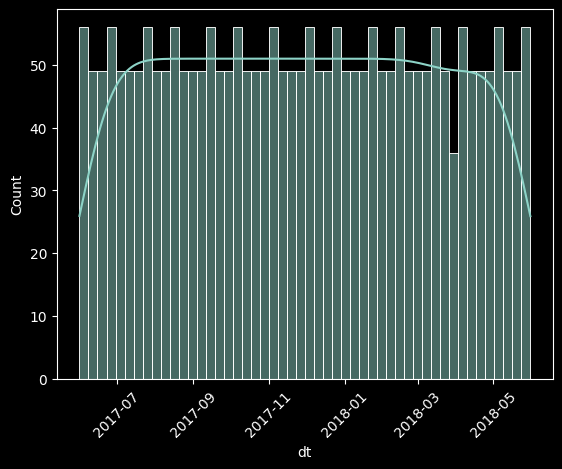

In [32]:
plt.xticks(rotation=45)  # gira las etiquetas en el eje X
sns.histplot(costs['dt'], bins=50, kde=True)

In [33]:
costs['month'] = costs['dt'].astype('datetime64[M]')
monthly_costs = costs.groupby('month').sum()
monthly_costs

,source_id,costs
month,,
2017-06-01,1020,18015.00
2017-07-01,1054,18240.59
2017-08-01,1054,14790.54
2017-09-01,1020,24368.91
2017-10-01,1054,36322.88
2017-11-01,1020,37907.88
2017-12-01,1054,38315.35
2018-01-01,1054,33518.52
2018-02-01,952,32723.03


In [34]:
total_spend = costs['costs'].sum()
print(f"Gasto total en marketing: ${total_spend}")

Gasto total en marketing: $329131.62


In [35]:
source_id_costs = costs.groupby('source_id').sum()
source_id_costs

,costs
source_id,
1,20833.27
2,42806.04
3,141321.63
4,61073.60
5,51757.10
9,5517.49
10,5822.49


In [36]:
report_ = pd.merge(report, monthly_costs,
                   left_on='first_order_month', right_on='month')
report_['cac'] = report_['costs'] / report_['n_buyers']
report_.head()

,first_order_month,n_buyers,order_month,Revenue,age,gp,ltv,source_id,costs,cac
0,2017-06-01,2023,2017-06-01,9557.49,0,9557.49,4.724414,1020,18015.0,8.905091
1,2017-06-01,2023,2017-07-01,981.82,1,981.82,0.485329,1020,18015.0,8.905091
2,2017-06-01,2023,2017-08-01,885.34,2,885.34,0.437637,1020,18015.0,8.905091
3,2017-06-01,2023,2017-09-01,1931.30,3,1931.30,0.954671,1020,18015.0,8.905091
4,2017-06-01,2023,2017-10-01,2068.58,4,2068.58,1.022531,1020,18015.0,8.905091


In [37]:
report_['romi'] = report_['ltv'] / report_['cac']
result = report_.pivot_table(
    index='first_order_month',
    columns='age',
    values='romi',
    aggfunc='mean')

result.cumsum(axis=1).round(2)
result.fillna('')

age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,0.530530,0.0545,0.049145,0.107205,0.114825,0.082593,0.10673,0.06531,0.062123,0.068027,0.06415,0.028844
2017-07-01,0.633623,0.035339,0.065735,0.037845,0.018638,0.016451,0.012673,0.014951,0.016998,0.015513,0.016412,
2017-08-01,0.488747,0.043719,0.042468,0.036243,0.045762,0.026263,0.019513,0.037515,0.027067,0.017412,,
2017-09-01,0.597833,0.118368,0.055174,0.421091,0.042425,0.068533,0.07431,0.025753,0.019489,,,
2017-10-01,0.597866,0.064015,0.022869,0.018776,0.018109,0.014381,0.010134,0.013797,,,,
2017-11-01,0.554931,0.04298,0.021483,0.034983,0.015934,0.0058,0.012373,,,,,
2017-12-01,0.542015,0.029785,0.105824,0.12186,0.035797,0.03867,,,,,,
2018-01-01,0.416173,0.029662,0.03062,0.014368,0.006309,,,,,,,
2018-02-01,0.463807,0.031048,0.00876,0.008272,,,,,,,,


In [38]:
result.cumsum(axis=1).mean(axis=0)

age
0     0.540816
1     0.581985
2     0.631069
3     0.719740
4     0.782946
5     0.859876
6     0.896819
7     0.969951
8     1.053871
9     0.964488
10    1.094658
11    1.333982
dtype: float64

# Conclusiones
* Recomendaría las plataforma 1 ya que es la mas utilizada en los meses con mayor % de ROMI positivo con lo cual ayudaria a que el flujo de clientes sea mayor concretando mejores compras 